# Ocelot MachineLayout: Survey and 2D/3D Layout Plotting

This document explains the concepts behind the Ocelot survey and layout tools and how they are intended to be used.

It covers:

1. Beamline geometry surveys using `MagneticLattice`
2. The meaning of survey output data
3. Why and when to use the higher-level `MachineLayout`
4. 2D and 3D visualization concepts
5. Interference (collision) checks
6. Practical usage tips

The focus here is on **concepts and data structures**, not on code details.

---

## Overview

In Ocelot, the geometric layout of a beamline or facility is described using a **survey**.
A survey computes the **global positions and orientations** of beamline elements starting from a given reference point.

> **Key idea:**  
> The survey determines where the beamline is in the global laboratory frame and how it is oriented at each point.

---

## Requirements

- Core survey and layout functionality requires only Ocelot and its numerical dependencies.
- **2D plotting** relies on standard plotting libraries.
- **3D plotting (optional)** requires **Plotly**.

If Plotly is not installed, all survey functionality and 2D visualization remain available.

> **Note:**  
> Plotly is used only for interactive 3D visualization and is intentionally kept outside `ocelot.cpbd`.


In [1]:

from ocelot import *

# New survey class / plotting
from ocelot.cpbd.layout import MachineLayout
from ocelot.gui.layout_2d import plot_layout_2d
from ocelot.gui.layout_3d import plot_layout_3d

initializing ocelot...


## `MagneticLattice.survey()`

Before introducing the higher-level `MachineLayout`, it is important to understand the
**low-level geometric survey** provided by `MagneticLattice`.

---

## What does `MagneticLattice.survey()` compute?

`MagneticLattice.survey()` performs a **3D geometric survey of the reference trajectory**
using a recursive vector/matrix formalism consistent with **MAD-8 survey conventions**
(as described in the *MAD-8 Physics Guide*).

The survey propagates along the beamline, element by element:

- the global **position vector**  
- the local-to-global **rotation matrix**

This approach is identical in spirit to the classical MAD-8 survey procedure and ensures
that tilt, bending, and orientation are treated consistently.

---

## Survey output structure

The survey returns **two lists of dictionaries**:

- **Midpoint survey data**
  - Data evaluated at the geometric center of each element
  - Intended mainly for tables, inspection, and diagnostics

- **Endpoint survey data**
  - Data evaluated at the exit of each element
  - Intended for plotting, connectivity, branching, and layout logic

This separation avoids ambiguity and ensures that midpoint information is never
accidentally used for connectivity or branching.

---

## Contents of a survey record

Each entry in the survey output is a **dictionary** describing the beamline state
at a specific location.

The most important fields are:

- **`r_start`**  
  Global position at the **entrance** of the element

- **`r_end`**  
  Global position at the **exit** of the element

- **`W_start`**  
  Rotation matrix at the element entrance

- **`W`**  
  Rotation matrix at the survey record location  
  (midpoint for midpoint data, exit for endpoint data)

- **`X, Y, Z`**  
  Scalar global coordinates of the record location (convenience values)

- **`THETA, PHI, PSI`**  
  Orientation angles derived from the rotation matrix

- **`XPD, YPD, ZPD`**  
  Direction cosines of the local **s-axis** (beam direction) in global coordinates

- **`element`**  
  Reference to the corresponding Ocelot element instance

Together, these quantities fully describe the beamline geometry in 3D space.

---

## Meaning of the rotation matrix `W`

The rotation matrix `W` maps vectors from the **local element frame** `(x, y, s)`
to the **global laboratory frame** `(X, Y, Z)`:

$$
\mathbf{v}_{\mathrm{global}} = W \, \mathbf{v}_{\mathrm{local}}
$$

The columns of `W` have a direct geometric meaning:

- `W[:, 0]` — local **x-axis** in global coordinates  
- `W[:, 1]` — local **y-axis** in global coordinates  
- `W[:, 2]` — local **s-axis**, i.e. the beam direction

This representation follows standard MAD-8 conventions.

---

## Simple usage of `survey()`

For a single beamline, `MagneticLattice.survey()` is sufficient to:

- inspect global positions and angles
- verify bending and tilt behavior
- produce simple 2D plots (e.g. top or side views)
- debug element geometry

At this level, the user works directly with the list of survey dictionaries.


Number of records: 5
Keys in one record:
dict_keys(['LENGTH', 'TILT', 'S', 'X', 'Y', 'Z', 'THETA', 'PHI', 'PSI', 'XPD', 'YPD', 'ZPD', 'W', 'W_start', 'r_start', 'r_end', 'element'])


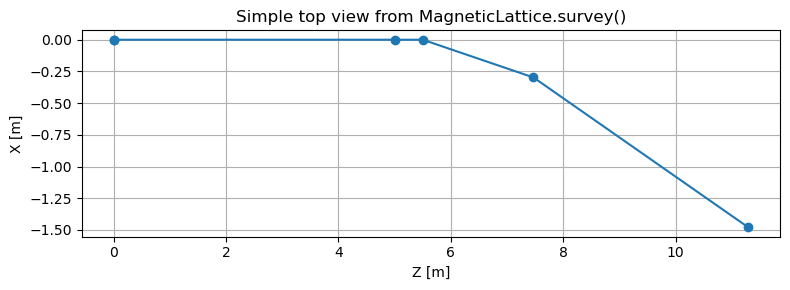

In [2]:
import matplotlib.pyplot as plt
lat = MagneticLattice([
    Drift(l=5, eid="d1"),
    Quadrupole(l=0.5, eid="q1"),
    SBend(l=2.0, angle=0.3, eid="b1"),
    Drift(l=4, eid="d2"),
])

mid, end = lat.survey()

print("Number of records:", len(end))
print("Keys in one record:")
print(end[0].keys())

# simple matplotlib plotting

# Extract centerline points
X = [p["r_start"][0] for p in end]
Z = [p["r_start"][2] for p in end]

# add final exit point
X.append(end[-1]["r_end"][0])
Z.append(end[-1]["r_end"][2])

plt.figure(figsize=(8, 3))
plt.plot(Z, X, "-o")
plt.xlabel("Z [m]")
plt.ylabel("X [m]")
plt.title("Simple top view from MagneticLattice.survey()")
plt.grid(True)
plt.tight_layout()
plt.show()

## Why do we need `MachineLayout`?

While `MagneticLattice.survey()` works well for a **single beamline**, it becomes
inconvenient when dealing with more complex layouts.

Typical limitations include:

- no native support for **multiple beamlines**
- no notion of **branching**
- manual handling of global coordinates
- no automatic interference checks

To address these use cases, Ocelot provides the higher-level class **`MachineLayout`**.

---

## `MachineLayout` class

`MachineLayout` is a high-level container for the **geometric layout of a facility** composed of multiple
beamlines (`MagneticLattice`), including branches. It is built on top of `MagneticLattice.survey()` and follows
MAD-8 survey conventions for position/orientation propagation.

`MachineLayout` is **geometry-only**: it does not affect tracking or optics. Its purpose is to:
- survey several beamlines in a common global frame,
- connect child lines to a parent line at a named anchor element,
- support facility-level plotting (2D/3D) and coarse interference checks.

### Key semantics

- **Survey-driven geometry:** all positions/orientations come from `MagneticLattice.survey()`.
- **Explicit branching:** a child line attaches to a parent line by `anchor_element_id`.
- **Endpoint anchoring:** branching always happens at the **exit** of the anchor element (`r_end`, `W`).
- **Parent-first evaluation:** surveys are computed in parent-first order (independent of `add_line()` order).

### Methods

- **`add_line(name, lattice, parent_name=None, anchor_element_id=None)`**  
  Register a beamline. If `parent_name` is given, the beamline is treated as a branch starting at the
  exit of `anchor_element_id` in the parent line.

- **`survey()`**  
  Compute surveys for all registered lines in parent-first order and cache the results in `self._surveys`.
  Returns a dictionary `{line_name: end_survey_data}`.

- **`check_interferences(min_distance=0.1)`**  
  Coarse collision check between beamlines. Computes the minimum distance between element centerline
  segments and compares it to an effective radius based on element `width` (fallback to `min_distance`).

### Stored data

After calling `survey()`, survey results are available via:
- `self._surveys[line_name]` → the **endpoint survey list** for that line.

## Example of multi beamline layout 
We start with main beam line, for this we initialize new `MagneticLattice` object 

> Notes in Ocelot version >25.12 we have new atributes for elements `width`, `height`, `color` are purely for plotting/visualization of survey function:

In [11]:
# Main beamline (root)
main_linac = MagneticLattice([
    Drift(l=5, eid="d1", width=0.05, height=0.05),   # cylinder-like in 3D
    Quadrupole(l=0.5, eid="q1", width=0.25, height=0.25, color="red"),
    Drift(l=1, eid="d2"),
    SBend(l=2, angle=0.25, eid="b1", width=0.35, height=0.35, color="steelblue"),
    Drift(l=3, eid="d3"),
    Quadrupole(l=0.5, eid="q2", width=0.25, height=0.25, color="red"),
])

Note:
* `width`, `height`, `color` are purely for plotting/visualization.
* `SBend(..., angle=...)` determines curvature in survey geometry.
* `tilt` rotates around the local s-axis (e.g. skew quad or vertical bend).

## Add a branch line

In [12]:
# A branch (child) beamline that starts after some element in the parent line
dump_line = MagneticLattice([
    Drift(l=1, eid="dd1"),
    SBend(l=2, angle=0.45, eid="db1", tilt=np.pi/2, width=0.30, height=0.30, color="crimson"),  # "vertical" bend
    Drift(l=4, eid="dd2"),
])

## Build the facility graph

In [13]:
facility = MachineLayout()

facility.add_line("Main", main_linac)

# Attach Dump after element "b1" in Main
facility.add_line("Dump", dump_line, parent_name="Main", anchor_element_id="b1")

## Run survey and inspect output 

In [14]:
surveys = facility.survey()

print("Lines computed:", list(surveys.keys()))
print("Number of records in Main:", len(surveys["Main"]))
print("Keys of one record:", list(surveys["Main"][0].keys()))

Lines computed: ['Main', 'Dump']
Number of records in Main: 7
Keys of one record: ['LENGTH', 'TILT', 'S', 'X', 'Y', 'Z', 'THETA', 'PHI', 'PSI', 'XPD', 'YPD', 'ZPD', 'W', 'W_start', 'r_start', 'r_end', 'element']


## Inspect one element record

In [15]:
rec = surveys["Main"][3]  # pick any record
el = rec["element"]

print("Element:", el.__class__.__name__, el.id)
print("r_start:", rec["r_start"])
print("r_end  :", rec["r_end"])

W = rec["W"]
print("W[:,2] (beam direction) =", W[:,2])

Element: Drift d2
r_start: [0.  0.  5.5]
r_end  : [0.  0.  6.5]
W[:,2] (beam direction) = [0. 0. 1.]


## Visualization concepts

### 2D visualization

2D plotting typically provides:

- **Top view:** X vs Z
- **Side view:** Y vs Z

This representation is well suited for:
- quick geometry checks
- publications and reports
- debugging beamline curvature

Aspect ratios can be enforced so that transverse dimensions are not distorted.


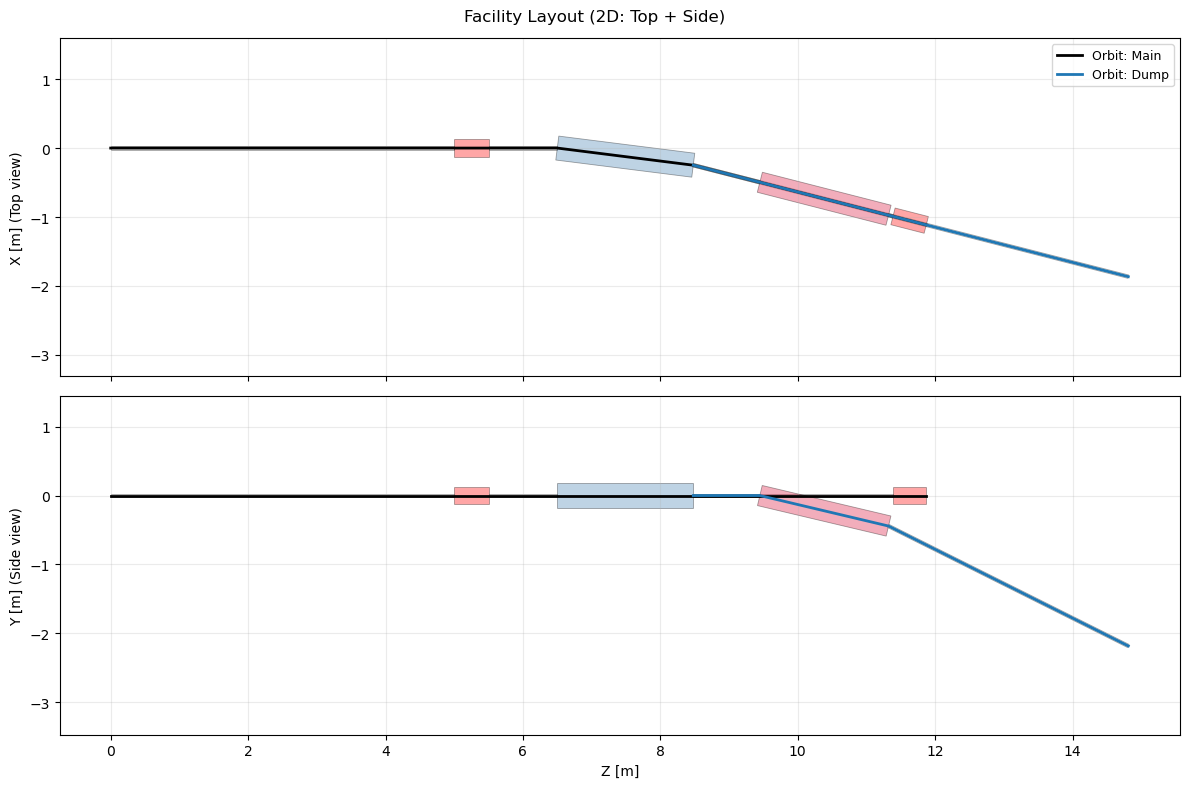

In [16]:
fig, (ax_top, ax_side) = plot_layout_2d(
    facility,
    show_orbit=True,
    show_elements=True,
    equal_aspect=True,
    title="Facility Layout (2D: Top + Side)"
)

### 3D visualization ([Plotly](https://plotly.com))

3D visualization provides an intuitive representation of the entire facility:

- reference trajectories are drawn as lines
- elements are rendered as boxes or cylinders
- visual dimensions are controlled via element attributes

Important implementation details:

- element bodies are positioned using `r_start` and `W_start`
- X and Y axes are scaled equally so that round elements remain round
- element geometry is rigidly attached to the beamline orientation

---

## Visualization-only element attributes

Starting from Ocelot version ≥ 25.12, elements support additional attributes used
**only for visualization**:

- **`width`** — transverse size in the x-direction
- **`height`** — transverse size in the y-direction
- **`color`** — display color for plotting

These attributes do **not** affect beam dynamics or tracking.

---

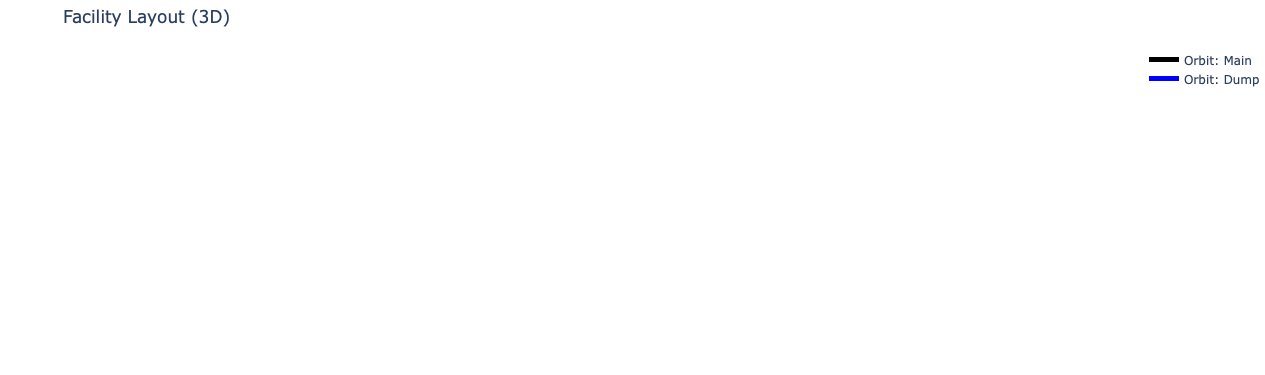

In [17]:
fig = plot_layout_3d(
    facility,
    show_orbit=True,
    show_elements=True,
    title="Facility Layout (3D)"
)
fig.show()

## Interference checks

`check_interferences()` computes minimum distance between element centerline segments of different beamlines.

This is a **coarse** check (segment-to-segment distance + width-based radius), but very useful to catch obvious overlaps.

In [10]:
collisions = facility.check_interferences(min_distance=0.10)

if collisions:
    print(f"🚨 Found {len(collisions)} collisions:")
    for (lineA, elA, lineB, elB, dist) in collisions:
        print(f"  {lineA}.{elA} <-> {lineB}.{elB}  dist={dist:.4f} m")
else:
    print("✅ No collisions detected.")

🚨 Found 3 collisions:
  Main.b1 <-> Dump.dd1  dist=0.0000 m
  Main.d3 <-> Dump.dd1  dist=0.0000 m
  Main.d3 <-> Dump.db1  dist=0.0000 m


## Practical tips

### 1) Using `tilt`
- Quad: `tilt = π/4` → skew quad (visual + optics meaning)
- Bend: `tilt = π/2` → vertical bend (survey & visual)

### 2) Choosing `width` and `height`
- Use physical magnet yoke size if you want realistic pictures.
- If you just want readability, pick a few standard sizes:
  - drifts/cavities: ~0.1–0.2 m
  - quads/sexts: ~0.2–0.4 m
  - bends: ~0.3–0.6 m

### 3) Anchor semantics for branches
A child line starts at the **exit** of the anchor element in the parent line and inherits the parent’s orientation at that point.